In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from geographiclib.geodesic import Geodesic

DATA_DIR = Path("./data")
TRACK_DIR = DATA_DIR / "track_interval1h"
BEST_TRACK_FILE = DATA_DIR / "best_track_Ragasa_JMA.xlsx"
OUTPUT_FILE = Path("track_error_barplot.tif")

FORECAST_INIT_TIMES = {
    "24h": pd.Timestamp("2025-09-22 22:00"),
    "48h": pd.Timestamp("2025-09-21 22:00"),
}
MODEL_STYLES = {
    "era5": {"label": "ERA5", "color": "#4c78a8"},
    "pangu": {"label": "Pangu", "color": "#f58518"},
    "graphcast": {"label": "GraphCast", "color": "#54a24b"},
    "fengwu": {"label": "FengWu", "color": "#e45756"},
    "fuxi": {"label": "FuXi", "color": "#72b7b2"},
    "aurora": {"label": "Aurora", "color": "#b279a2"},
}

PLOT_SETTINGS = {
    # Wide but short (reduce perceived bar height)
    "figure_size": (8, 4),
    "cycle_order": ["24h", "48h"],
    # Match Fig4/02_rmse_all_stations lead colors
    "cycle_colors": {"24h": "#6E8BC3", "48h": "#C96A5A"},
    "cycle_label_map": {"24h": "24-h", "48h": "48-h"},
    "bar_width": 0.36,
    "label_fontsize": 16,
    "text_fontsize": 14,
}

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14


def load_track_forecast(model_name, cycle_name, init_time):
    file_path = TRACK_DIR / f"track_d01_interval1h_{model_name}_{cycle_name}.txt"
    values = np.loadtxt(file_path)
    lead_hours = np.arange(values.shape[0], dtype=int)

    return pd.DataFrame(
        {
            "model": model_name,
            "cycle": cycle_name,
            "lead_hour": lead_hours,
            "init_time": pd.Timestamp(init_time),
            "valid_time": pd.Timestamp(init_time) + pd.to_timedelta(lead_hours, unit="h"),
            "lon": values[:, 0],
            "lat": values[:, 1],
            "slp_hpa": values[:, 2],
        }
    )


def load_best_track(file_path):
    renamed_columns = {
        "Time": "time",
        "Lat": "lat_tenths",
        "Lon": "lon_tenths",
        "Pres": "pres_hpa",
        "Wind": "wind_kt",
    }

    return (
        pd.read_excel(file_path)
        .rename(columns=renamed_columns)
        .assign(
            time=lambda frame: pd.to_datetime(frame["time"].astype(str), format="%y%m%d%H"),
            lat=lambda frame: frame["lat_tenths"] / 10,
            lon=lambda frame: frame["lon_tenths"] / 10,
        )
        [["time", "lat", "lon", "pres_hpa", "wind_kt"]]
        .sort_values("time")
        .reset_index(drop=True)
    )


def load_all_track_forecasts():
    return {
        cycle_name: {
            model_name: load_track_forecast(model_name, cycle_name, init_time)
            for model_name in MODEL_STYLES
        }
        for cycle_name, init_time in FORECAST_INIT_TIMES.items()
    }


track_best = load_best_track(BEST_TRACK_FILE)
track_forecasts = load_all_track_forecasts()

In [4]:
def geodesic_distance_km(lon1, lat1, lon2, lat2):
    return np.array(
        [
            Geodesic.WGS84.Inverse(lat_a, lon_a, lat_b, lon_b)["s12"] / 1000.0
            for lon_a, lat_a, lon_b, lat_b in zip(lon1, lat1, lon2, lat2)
        ]
    )


def get_best_track_steps(track_best_frame, cycle_name, cycle_forecasts):
    forecast_start = FORECAST_INIT_TIMES[cycle_name]
    forecast_end = min(track["valid_time"].max() for track in cycle_forecasts.values())

    best_track_window = (
        track_best_frame.loc[track_best_frame["time"].between(forecast_start, forecast_end)]
        .copy()
        .sort_values("time")
    )

    return best_track_window.rename(
        columns={"time": "valid_time", "lon": "best_lon", "lat": "best_lat"}
    )[["valid_time", "best_lon", "best_lat"]]


def compute_track_error_table(track_best_frame, forecast_map):
    error_frames = []

    for cycle_name, cycle_forecasts in forecast_map.items():
        best_track_steps = get_best_track_steps(track_best_frame, cycle_name, cycle_forecasts)

        for model_name, forecast_track in cycle_forecasts.items():
            aligned_track = (
                forecast_track.merge(best_track_steps, on="valid_time", how="inner")
                .sort_values("valid_time")
                .reset_index(drop=True)
            )
            aligned_track["track_error_km"] = geodesic_distance_km(
                aligned_track["lon"].to_numpy(),
                aligned_track["lat"].to_numpy(),
                aligned_track["best_lon"].to_numpy(),
                aligned_track["best_lat"].to_numpy(),
            )
            error_frames.append(
                aligned_track[
                    [
                        "cycle",
                        "model",
                        "lead_hour",
                        "valid_time",
                        "lon",
                        "lat",
                        "best_lon",
                        "best_lat",
                        "track_error_km",
                    ]
                ]
            )

    return pd.concat(error_frames, ignore_index=True)


def summarize_track_error(track_error_frame):
    return (
        track_error_frame.groupby(["cycle", "model"], as_index=False)["track_error_km"]
        .mean()
        .rename(columns={"track_error_km": "mae_km"})
    )


def format_track_error_summary(track_error_summary_frame):
    return (
        track_error_summary_frame.assign(
            model=lambda frame: frame["model"].map(lambda name: MODEL_STYLES[name]["label"])
        )
        .sort_values(["model", "cycle"])
        .reset_index(drop=True)
    )


track_error_table = compute_track_error_table(track_best, track_forecasts)
track_error_summary = summarize_track_error(track_error_table)

track_error_table.head(), format_track_error_summary(track_error_summary)

(  cycle model  lead_hour          valid_time       lon      lat  best_lon  \
 0   24h  era5          2 2025-09-23 00:00:00  118.5446  19.9933     118.3   
 1   24h  era5          8 2025-09-23 06:00:00  117.2320  20.7317     117.1   
 2   24h  era5         14 2025-09-23 12:00:00  115.9194  20.9770     116.0   
 3   24h  era5         20 2025-09-23 18:00:00  114.8693  21.2219     114.8   
 4   24h  era5         26 2025-09-24 00:00:00  113.8192  21.2219     113.6   
 
    best_lat  track_error_km  
 0      19.9       27.609989  
 1      20.4       39.217439  
 2      20.8       21.315667  
 3      21.2        7.592573  
 4      21.3       24.338420  ,
    cycle      model     mae_km
 0    24h     Aurora  28.786551
 1    48h     Aurora  41.828761
 2    24h       ERA5  23.833749
 3    48h       ERA5  33.153038
 4    24h     FengWu  46.583058
 5    48h     FengWu  50.785134
 6    24h       FuXi  32.270034
 7    48h       FuXi  42.534804
 8    24h  GraphCast  30.552794
 9    48h  GraphCast  3

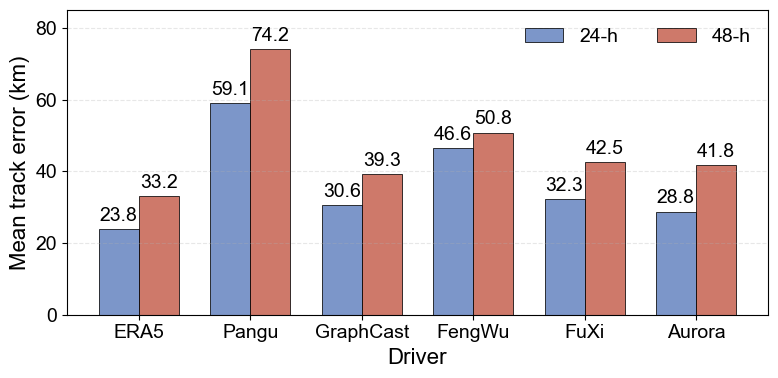

,cycle,model,mae_km
0,24h,Aurora,28.786551
1,48h,Aurora,41.828761
2,24h,ERA5,23.833749
3,48h,ERA5,33.153038
4,24h,FengWu,46.583058
5,48h,FengWu,50.785134
6,24h,FuXi,32.270034
7,48h,FuXi,42.534804
8,24h,GraphCast,30.552794
9,48h,GraphCast,39.315821


In [5]:
def plot_track_error_summary(track_error_summary_frame):
    figure, axis = plt.subplots(figsize=PLOT_SETTINGS["figure_size"])
    model_order = list(MODEL_STYLES)
    x_positions = np.arange(len(model_order), dtype=float)

    for cycle_index, cycle_name in enumerate(PLOT_SETTINGS["cycle_order"]):
        cycle_summary = (
            track_error_summary_frame.loc[track_error_summary_frame["cycle"] == cycle_name]
            .set_index("model")
            .reindex(model_order)
            .reset_index()
        )
        x_offset = (cycle_index - 0.5) * PLOT_SETTINGS["bar_width"]
        cycle_label = PLOT_SETTINGS.get("cycle_label_map", {}).get(cycle_name, cycle_name)
        bars = axis.bar(
            x_positions + x_offset,
            cycle_summary["mae_km"],
            width=PLOT_SETTINGS["bar_width"],
            label=cycle_label,
            color=PLOT_SETTINGS["cycle_colors"][cycle_name],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
        )
        axis.bar_label(
            bars,
            fmt="%.1f",
            padding=3,
            fontsize=PLOT_SETTINGS["text_fontsize"],
        )

    axis.set_xticks(x_positions)
    axis.set_xticklabels(
        [MODEL_STYLES[model_name]["label"] for model_name in model_order],
        rotation=0,
        fontsize=PLOT_SETTINGS["text_fontsize"],
    )
    axis.tick_params(axis="y", labelsize=PLOT_SETTINGS["text_fontsize"])
    axis.set_ylabel("Mean track error (km)", fontsize=PLOT_SETTINGS["label_fontsize"])
    axis.set_xlabel("Driver", fontsize=PLOT_SETTINGS["label_fontsize"])
    axis.set_ylim(0, 85)
    axis.grid(axis="y", linestyle="--", alpha=0.3)
    axis.legend(
        frameon=False,
        loc="upper right",
        ncol=2,
        fontsize=PLOT_SETTINGS["text_fontsize"],
        title_fontsize=PLOT_SETTINGS["text_fontsize"],
    )

    figure.tight_layout()
    figure.savefig(OUTPUT_FILE, dpi=600, format="tif", bbox_inches="tight")
    return figure, axis


fig, ax = plot_track_error_summary(track_error_summary)
plt.show()

format_track_error_summary(track_error_summary)

In [ ]:
# Self-contained Ragasa + Yagi mean track-error heatmap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyproj import Geod

HEATMAP_INPUT_DIR = Path("./input")
HEATMAP_OUTPUT_DIR = Path("./output")
HEATMAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HEATMAP_OUTPUT_FILE = HEATMAP_OUTPUT_DIR / "track_error_heatmap.tif"

HEATMAP_MODELS = {
    "era5": "ERA5",
    "pangu": "Pangu",
    "graphcast": "GraphCast",
    "fengwu": "FengWu",
    "fuxi": "FuXi",
    "aurora": "Aurora",
}
HEATMAP_CYCLES = ("24h", "48h")
HEATMAP_STORM_CONFIG = {
    "Ragasa": {
        "track_dir": HEATMAP_INPUT_DIR / "track_interval1h_ragasa",
        "file_template": "track_d01_interval1h_{model}_{cycle}.txt",
        "best_track_file": HEATMAP_INPUT_DIR / "best_track_Ragasa_JMA.xlsx",
        "time_step_hours": 1,
        "init_times": {
            "24h": pd.Timestamp("2025-09-22 22:00"),
            "48h": pd.Timestamp("2025-09-21 22:00"),
        },
        "end_time": pd.Timestamp("2025-09-24 10:00"),
        "expected_points": {"24h": 6, "48h": 10},
    },
    "Yagi": {
        "track_dir": HEATMAP_INPUT_DIR / "track_interval6h_yagi",
        "file_template": "track_yagi_{model}_{cycle}.txt",
        "best_track_file": HEATMAP_INPUT_DIR / "best_track_Yagi_JMA.xlsx",
        "time_step_hours": 6,
        "init_times": {
            "24h": pd.Timestamp("2024-09-04 12:00"),
            "48h": pd.Timestamp("2024-09-03 12:00"),
        },
        "end_time": pd.Timestamp("2024-09-06 00:00"),
        "expected_points": {"24h": 6, "48h": 10},
    },
}
HEATMAP_ROW_ORDER = [
    "Ragasa 24-h",
    "Ragasa 48-h",
    "Yagi 24-h",
    "Yagi 48-h",
]
WGS84_GEOD = Geod(ellps="WGS84")


def load_heatmap_best_track(file_path):
    best_track = (
        pd.read_excel(file_path)
        .rename(
            columns={
                "Time": "valid_time",
                "Lat": "best_lat_tenths",
                "Lon": "best_lon_tenths",
            }
        )
        .assign(
            valid_time=lambda frame: pd.to_datetime(
                frame["valid_time"].astype(str), format="%y%m%d%H"
            ),
            best_lat=lambda frame: frame["best_lat_tenths"] / 10,
            best_lon=lambda frame: frame["best_lon_tenths"] / 10,
        )
        [["valid_time", "best_lon", "best_lat"]]
        .sort_values("valid_time")
        .reset_index(drop=True)
    )
    assert np.isfinite(best_track[["best_lon", "best_lat"]]).all().all()
    return best_track


def load_heatmap_forecast(storm_name, model_name, cycle_name):
    config = HEATMAP_STORM_CONFIG[storm_name]
    file_path = config["track_dir"] / config["file_template"].format(
        model=model_name, cycle=cycle_name
    )
    values = np.atleast_2d(np.loadtxt(file_path))
    assert values.shape[1] >= 2 and np.isfinite(values[:, :2]).all(), file_path

    lead_hours = np.arange(values.shape[0], dtype=int) * config["time_step_hours"]
    init_time = config["init_times"][cycle_name]
    return pd.DataFrame(
        {
            "storm": storm_name,
            "cycle": cycle_name,
            "model": model_name,
            "valid_time": init_time + pd.to_timedelta(lead_hours, unit="h"),
            "forecast_lon": values[:, 0],
            "forecast_lat": values[:, 1],
        }
    )


def build_heatmap_track_errors():
    error_frames = []

    for storm_name, config in HEATMAP_STORM_CONFIG.items():
        best_track = load_heatmap_best_track(config["best_track_file"])
        for cycle_name in HEATMAP_CYCLES:
            for model_name in HEATMAP_MODELS:
                forecast = load_heatmap_forecast(storm_name, model_name, cycle_name)
                aligned = (
                    forecast.loc[forecast["valid_time"] <= config["end_time"]]
                    .merge(best_track, on="valid_time", how="inner", validate="one_to_one")
                    .sort_values("valid_time")
                    .reset_index(drop=True)
                )
                if storm_name == "Yagi":
                    aligned = aligned.iloc[1:].reset_index(drop=True)
                expected_points = config["expected_points"][cycle_name]
                assert len(aligned) == expected_points, (
                    storm_name, cycle_name, model_name, len(aligned)
                )

                _, _, distance_m = WGS84_GEOD.inv(
                    aligned["forecast_lon"].to_numpy(),
                    aligned["forecast_lat"].to_numpy(),
                    aligned["best_lon"].to_numpy(),
                    aligned["best_lat"].to_numpy(),
                )
                aligned["track_error_km"] = distance_m / 1000.0
                assert np.isfinite(aligned["track_error_km"]).all()
                error_frames.append(aligned)

    return pd.concat(error_frames, ignore_index=True)


heatmap_track_errors = build_heatmap_track_errors()
heatmap_track_error_summary = (
    heatmap_track_errors.groupby(
        ["storm", "cycle", "model"], as_index=False, sort=False
    )["track_error_km"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "mean_track_error_km"})
)
heatmap_track_error_summary["row_label"] = (
    heatmap_track_error_summary["storm"]
    + " "
    + heatmap_track_error_summary["cycle"].map({"24h": "24-h", "48h": "48-h"})
)

heatmap_data = (
    heatmap_track_error_summary.pivot(
        index="row_label", columns="model", values="mean_track_error_km"
    )
    .reindex(index=HEATMAP_ROW_ORDER, columns=list(HEATMAP_MODELS))
    .rename(columns=HEATMAP_MODELS)
)
assert heatmap_data.shape == (4, 6)
assert np.isfinite(heatmap_data.to_numpy()).all()
assert heatmap_data.to_numpy().min() >= 20
assert heatmap_data.to_numpy().max() <= 85
heatmap_data.index = ["Ragasa 24h", "Ragasa 48h", "Yagi 24h", "Yagi 48h"]

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14
figure, axis = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Mean track error (km)", "pad": 0.02},
    annot_kws={"fontsize": 13},
    ax=axis,
)
axis.axhline(2, color="black", linewidth=1.5)
axis.set_xlabel("Driver", fontsize=16)
axis.set_ylabel("")
axis.set_xticklabels(axis.get_xticklabels(), rotation=0, fontsize=13)
axis.set_yticklabels(axis.get_yticklabels(), rotation=0, fontsize=13)
figure.tight_layout()
figure.savefig(HEATMAP_OUTPUT_FILE, dpi=600, format="tif", bbox_inches="tight")
plt.show()

heatmap_data
